# Model Development & Tracking 
Covers **Stage 2.2–2.4 + Stage 3.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 

- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`. 
- *Provided to extend:* `src/model.py`, `src/train.py`, `app.py`. 
- *You build:* this notebook.

### 0. Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

import torch
import config
from src import data_prep
from src.model import build_model, trainable_parameters

print(f"PyTorch: {torch.__version__}")
print(f"Device: {config.DEVICE}")

PyTorch: 2.9.1+cpu
Device: cpu


## **Stage 2.2 — Transfer-Learning Model** <font color="red">[7 marks]</font>

- **2.2.1 — ImageNet-pretrained ResNet18, backbone frozen [4]**
- **2.2.2 — New 2-class head replaces fc (head trained) [3]**

**Objective:** Build an ImageNet-pretrained ResNet18 with a frozen backbone + new 2-class head.

**Implement in:** src/model.build_model

**Inputs → Outputs:** → a torch model; only the head's params have requires_grad=True

**TODO:** load weights=IMAGENET1K + freeze the backbone (2.2.1); replace fc with a 2-class Linear head so only the head trains (2.2.2); print total vs trainable params.

**Depends on:** Stage 2.1 transformations completed in Data_Preparation.ipynb  ·  **Document here:** the param counts (trainable should be ~the head only).

In [2]:
# 2.2.1-2.2.2: Build model + print params
net = build_model(freeze=config.FREEZE_BACKBONE)

total_params = sum(p.numel() for p in net.parameters())
trainable = trainable_parameters(net)
train_params = sum(p.numel() for p in trainable)

print(f"Model: {config.BACKBONE}")
print(f"Total parameters:     {total_params:>10,}")
print(f"Trainable parameters: {train_params:>10,}")
print(f"Frozen parameters:    {total_params - train_params:>10,}")
print(f"\nFinal layer (head):")
print(f"  {net.fc}")
print(f"\nBackbone frozen: {config.FREEZE_BACKBONE}")
print(f"Only the head trains: {all(not p.requires_grad for n, p in net.named_parameters() if 'fc' not in n)}")

Model: resnet18
Total parameters:     11,177,538
Trainable parameters:      1,026
Frozen parameters:    11,176,512

Final layer (head):
  Linear(in_features=512, out_features=2, bias=True)

Backbone frozen: True
Only the head trains: True


## **Stage 2.3 — Training Workflow** <font color="red">[6 marks]</font>

- **2.3.1 — Class-weighted loss + optimiser (trainable params) + seed [3]**
- **2.3.2 — Epoch loop + validation eval + early stopping [3]**

**Objective:** Train the head reproducibly with validation + early stopping.

**Implement in:** src/train.py

**Inputs → Outputs:** splits + model → trained model.pt + model_meta.json

**TODO:** class-weighted CrossEntropy + Adam over TRAINABLE params only + seed 42 (2.3.1); epoch loop with val evaluation + early stop on val-F1 (2.3.2).

**Document here:** the training summary (final val F1, epochs).

In [5]:
import sys
import subprocess
from pathlib import Path

req_file = Path('requirements.txt')
if req_file.exists():
    print('Installing project dependencies...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(req_file)])

!python -m src.train

Installing project dependencies...
[train] 2499 images  [val] 995  [test] 715
Parameters -- total: 11,177,538  trainable: 1,026
Epoch 1/4  loss=0.5284  val_f1=0.8954  val_recall=0.8121
Epoch 2/4  loss=0.3721  val_f1=0.9187  val_recall=0.8511
Epoch 3/4  loss=0.3162  val_f1=0.9646  val_recall=0.9433
Epoch 4/4  loss=0.3010  val_f1=0.9629  val_recall=0.9663

=== Test Metrics ===
  accuracy: 0.9287
  precision_defect: 0.9786
  recall_defect: 0.9073
  f1_defect: 0.9416
  macro_f1: 0.9250
  roc_auc: 0.9823

[OK] Registered casting_defect_classifier v4 -> @production
[OK] Saved reference baseline (200 images)


2026/07/29 15:46:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/29 15:47:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'casting_defect_classifier' already exists. Creating a new version of this model...
2026/07/29 15:47:25 WARNING mlflow.tracking._model_registry.fluent: Run with id 3bff495b513741e69f15389d91c8d59c has no artifacts at artifact path 'model', registering model based on models:/m-7463f890cc3a4e76b92425fb06fd916e instead
Created version '4' of model 'casting_defect_classifier'.


In [6]:
# Load and display training metadata
model_meta = json.loads(config.MODEL_META_PATH.read_text())
print("=== Training Summary ===")
print(json.dumps(model_meta, indent=2))

=== Training Summary ===
{
  "run_id": "3bff495b513741e69f15389d91c8d59c",
  "backbone": "resnet18",
  "freeze_backbone": true,
  "epochs_trained": 4,
  "best_val_f1": 0.9646418857660924,
  "test_metrics": {
    "accuracy": 0.9286713286713286,
    "precision_defect": 0.9785714285714285,
    "recall_defect": 0.9072847682119205,
    "f1_defect": 0.9415807560137457,
    "macro_f1": 0.9250094085275191,
    "roc_auc": 0.9822894022883913,
    "confusion_matrix": [
      [
        253,
        9
      ],
      [
        42,
        411
      ]
    ]
  },
  "total_params": 11177538,
  "trainable_params": 1026,
  "version": 4
}


## **Stage 2.4 — MLflow Experiment Tracking** <font color="red">[6 marks]</font>

- **2.4.1 — Params + per-epoch metrics logged [3]**
- **2.4.2 — Trained model logged to the run [3]**

**Objective:** Track the experiment in MLflow.

**Implement in:** src/train.py (mlflow calls)

**Inputs → Outputs:** training run → MLflow params + per-epoch metrics + logged model

**TODO:** set_experiment; log_params; log_metrics(step=epoch) (2.4.1); log_model (2.4.2).

**Document here:** the runs table (mlflow.search_runs).

In [10]:
import os
import subprocess
from pathlib import Path

import config

repo = Path.cwd().resolve()
venv_python = repo / ".venv" / "Scripts" / "python.exe"
if not venv_python.exists():
    raise FileNotFoundError(f"Project Python not found at {venv_python}")

code = '''
import os
import mlflow

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("file:./mlruns")
runs = mlflow.search_runs(experiment_names=["casting_defect_detection"])
display_cols = [
    c for c in runs.columns
    if c.startswith("params.") or c.startswith("metrics.test_") or c == "run_id" or c == "status"
]
print(f"Total runs: {len(runs)}")
print(runs[display_cols].to_string(index=False))
'''

result = subprocess.run(
    [str(venv_python), "-c", code],
    cwd=str(repo),
    capture_output=True,
    text=True,
    env={**os.environ, "MLFLOW_ALLOW_FILE_STORE": "true"},
)
print(result.stdout, end="")
if result.returncode != 0:
    print(result.stderr, end="")
    raise RuntimeError(f"MLflow query failed with exit code {result.returncode}")

Total runs: 4
                          run_id   status  metrics.test_recall_defect  metrics.test_f1_defect  metrics.test_precision_defect  metrics.test_roc_auc  metrics.test_macro_f1  metrics.test_accuracy params.backbone params.img_size params.learning_rate params.test_size params.max_train_images params.batch_size params.train_size params.freeze_backbone params.seed params.epochs params.val_split params.val_size params.weight_decay params.retrain params.corrupt_frac
3bff495b513741e69f15389d91c8d59c FINISHED                    0.907285                0.941581                       0.978571              0.982289               0.925009               0.928671        resnet18             224                0.001              715                    2500                32              2499                   True          42             4             0.15             995              0.0001           None                None
a3fd804b2f2d44b99d54e3a1db870ab2 FINISHED                         

## **Stage 3.1 — Evaluation & Failure Analysis** <font color="red">[7 marks]</font>

- **3.1.1 — Imbalance-aware metrics + model selection [4]**
- **3.1.2 — Confusion/ROC plots + failure-case analysis [3]**

**Objective:** Evaluate on defect recall/F1, not accuracy.

**Implement in:** src/evaluate.py

**Inputs → Outputs:** model + test split → metrics.json + model_eval.png

**TODO:** report recall(defect)/precision/F1/ROC-AUC + select on recall/F1 (3.1.1); plot ROC + confusion and inspect misclassified samples (3.1.2).

**Document here:** the metrics + a short interpretation (why recall matters here).

In [11]:
# 3.1.1: Load and display test metrics
metrics = json.loads(config.METRICS_PATH.read_text())
print("=== Test Metrics ===")
for k, v in metrics.items():
    if k != 'confusion_matrix':
        print(f"  {k}: {v:.4f}")
print(f"\nConfusion Matrix:")
print(f"  {metrics['confusion_matrix']}")

print("\n=== Why Recall Matters ===")
print("In casting defect detection, missing a defective part (false negative)")
print("is far more costly than flagging a good part (false positive).")
print("Recall on defects is the headline metric for quality control.")

=== Test Metrics ===
  accuracy: 0.9287
  precision_defect: 0.9786
  recall_defect: 0.9073
  f1_defect: 0.9416
  macro_f1: 0.9250
  roc_auc: 0.9823

Confusion Matrix:
  [[253, 9], [42, 411]]

=== Why Recall Matters ===
In casting defect detection, missing a defective part (false negative)
is far more costly than flagging a good part (false positive).
Recall on defects is the headline metric for quality control.


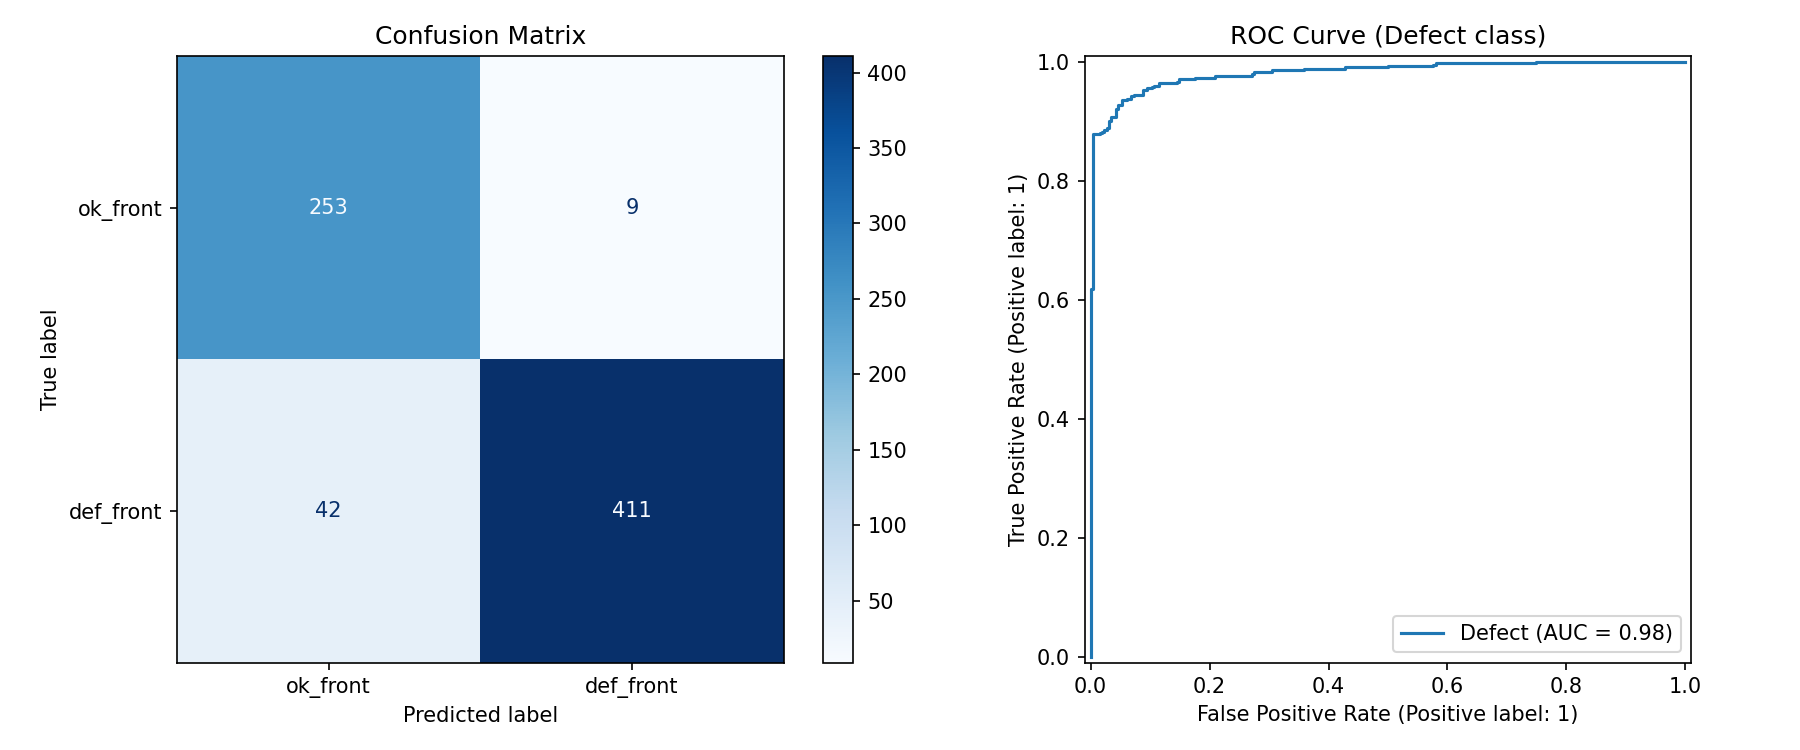

In [12]:
# 3.1.2: Show evaluation plots
from IPython.display import display, Image as IPImage
eval_plot = config.ARTIFACT_DIR / 'model_eval.png'
if eval_plot.exists():
    display(IPImage(filename=str(eval_plot)))
else:
    print("model_eval.png not found — run training first.")

## **Stage 3.2 — Model Registry & Promotion** <font color="red">[5 marks]</font>

- **3.2.1 — Best model registered in MLflow Registry [2]**
- **3.2.2 — Promotion to production alias + version history [3]**

**Objective:** Register and promote the best model.

**Implement in:** src/train.py (MLflow registry)

**Inputs → Outputs:** best run → registered model + @production alias

**TODO:** register_model(casting_defect_classifier) (3.2.1); set_registered_model_alias('production', v) with version history (3.2.2).

**Document here:** the registry version + alias (screenshot the MLflow Models page).

In [16]:
import os
import subprocess
from pathlib import Path

import config

repo = Path.cwd().resolve()
venv_python = repo / '.venv' / 'Scripts' / 'python.exe'
if not venv_python.exists():
    raise FileNotFoundError(f'Project Python not found at {venv_python}')

code = """
import os
import mlflow
from mlflow import MlflowClient
import config

os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('file:./mlruns')
client = MlflowClient()
mv = client.get_model_version_by_alias(config.REGISTERED_MODEL, config.PRODUCTION_ALIAS)
print(f'Registered Model: {config.REGISTERED_MODEL}')
print(f'Production Alias: @{config.PRODUCTION_ALIAS}')
print(f'Version: {mv.version}')
print(f'Run ID: {mv.run_id}')
print(f'Status: {mv.status}')
print('\\n=== Version History ===')
versions = client.search_model_versions(f\"name='{config.REGISTERED_MODEL}'\")
for v in versions:
    aliases = getattr(v, 'aliases', [])
    print(f\"  v{v.version} — run={v.run_id[:8]}... aliases={aliases}\")
"""

result = subprocess.run(
    [str(venv_python), '-c', code],
    cwd=str(repo),
    capture_output=True,
    text=True,
    env={**os.environ, 'MLFLOW_ALLOW_FILE_STORE': 'true'},
)
print(result.stdout, end='')
if result.returncode != 0:
    print(result.stderr, end='')
    raise RuntimeError(f'MLflow registry query failed with exit code {result.returncode}')

Registered Model: casting_defect_classifier
Production Alias: @production
Version: 4
Run ID: 3bff495b513741e69f15389d91c8d59c
Status: READY

=== Version History ===
  v4 â€” run=3bff495b... aliases=['production']
  v3 â€” run=a3fd804b... aliases=[]
  v2 â€” run=f7fee3db... aliases=[]
  v1 â€” run=bf2b5b46... aliases=[]


## **Stage 3.3 — FastAPI Inference Service** <font color="red">[6 marks]</font>

- **3.3.1 — Image /predict + /health + logging + validation [4]** — *to be done in app.py*
- **3.3.2 — Live call demonstrated in-notebook [2]** — *to be done in this notebook*

**Objective:** Serve the model behind an image API and demonstrate it.

**Implement in:** app.py (+ a TestClient demo here)

**Inputs → Outputs:** image upload → {label, prob_defect, confidence}; /health; predictions logged

**TODO:** implement /health + POST /predict (UploadFile) with validation (bad image 400, no-model 503) + logging (3.3.1, in app.py); demo with TestClient on a sample image (3.3.2, here).

**Document here:** the live request/response (TestClient output).

In [17]:
# 3.3.2: TestClient demo
from fastapi.testclient import TestClient
import app

with TestClient(app.app) as client:
    # Test /health
    resp = client.get('/health')
    print('=== GET /health ===')
    print(json.dumps(resp.json(), indent=2))
    
    # Test /predict with a sample image
    root = data_prep.find_data_root()
    sample = sorted((root / 'test' / 'def_front').glob('*.jpeg'))[0]
    print(f'\n=== POST /predict ({sample.name}) ===')
    with open(sample, 'rb') as f:
        resp = client.post('/predict', files={'file': (sample.name, f, 'image/jpeg')})
    print(json.dumps(resp.json(), indent=2))
    
    # Test with an OK image
    sample_ok = sorted((root / 'test' / 'ok_front').glob('*.jpeg'))[0]
    print(f'\n=== POST /predict ({sample_ok.name}) ===')
    with open(sample_ok, 'rb') as f:
        resp = client.post('/predict', files={'file': (sample_ok.name, f, 'image/jpeg')})
    print(json.dumps(resp.json(), indent=2))

=== GET /health ===
{
  "status": "ok",
  "model_loaded": true,
  "classes": {
    "ok_front": 0,
    "def_front": 1
  },
  "positive_class": "def_front",
  "test_metrics": {
    "accuracy": 0.9286713286713286,
    "precision_defect": 0.9785714285714285,
    "recall_defect": 0.9072847682119205,
    "f1_defect": 0.9415807560137457,
    "macro_f1": 0.9250094085275191,
    "roc_auc": 0.9822894022883913,
    "confusion_matrix": [
      [
        253,
        9
      ],
      [
        42,
        411
      ]
    ]
  },
  "model_version": 4
}

=== POST /predict (cast_def_0_1059.jpeg) ===
{
  "label": "def_front",
  "is_defective": true,
  "prob_defect": 0.5588,
  "confidence": 0.5588
}

=== POST /predict (cast_ok_0_10.jpeg) ===
{
  "label": "ok_front",
  "is_defective": false,
  "prob_defect": 0.3387,
  "confidence": 0.6613
}


## **Stage 3.4 — Containerisation & CI/CD** <font color="red">[7 marks]</font>

- **3.4.1 — Valid Dockerfile [3]** — *to be done in this notebook and the report*
- **3.4.2 — GitHub Actions CI + passing-test evidence [4]** — *to be done in this notebook and the report*

**Objective:** Containerise and automate tests.

**Implement in:** Dockerfile + .github/workflows/ci.yml (provided — review + evidence them)

**Inputs → Outputs:** code → Docker image; push/PR → CI runs pytest + docker build

**TODO:** show the Dockerfile (3.4.1); run pytest here + include a screenshot of the green CI run and successful docker build (3.4.2).

**Document here:** pytest output + Docker/CI screenshots **(Note: Don't add a repo link)**

In [18]:
# 3.4.1: Display Dockerfile
print('=== Dockerfile ===')
print(Path('Dockerfile').read_text())

# Display CI workflow
ci_path = Path('.github/workflows/ci.yml')
if ci_path.exists():
    print('\n=== .github/workflows/ci.yml ===')
    print(ci_path.read_text())

=== Dockerfile ===
# Casting Defect Detection â€” inference service image (CPU)
FROM python:3.11-slim

# libgl/libglib are needed by Pillow/torchvision image ops at runtime
RUN apt-get update && apt-get install -y --no-install-recommends \
        libgl1 libglib2.0-0 && rm -rf /var/lib/apt/lists/*

WORKDIR /app

# Install CPU-only torch wheels (smaller, no CUDA) then the rest
COPY requirements.txt .
RUN pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cpu \
        torch==2.8.0 torchvision==0.23.0 \
 && pip install --no-cache-dir \
        "mlflow==3.1.4" "fastapi==0.128.8" "uvicorn==0.39.0" "python-multipart==0.0.20" \
        "evidently==0.7.20" "scikit-learn==1.6.1" "pillow==11.3.0" numpy pandas matplotlib

# App code + trained model artifacts
COPY config.py app.py ./
COPY src ./src
COPY artifacts/model.pt artifacts/model_meta.json ./artifacts/

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]


=== .github/workflows/ci.yml ===
nam

In [19]:
# 3.4.2: Run pytest
!pytest -q

........                                                                 [100%]
8 passed in 22.97s
